C:\AppData\Local\Programs\Python\Python312\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\mzjin\AppData\Local\Temp\jieba.cache



读取文档数： 55

成功读取文档数： 55


Loading model cost 0.558 seconds.
Prefix dict has been built successfully.


词汇数： 1175
TF-IDF矩阵： (55, 1175)

分析特征量： 相对TF
文档相似度方法： 余弦相似度
余弦相似度分布 (min / median / max)： 0.0 / 0.0118 / 0.9083

文档相似网络
节点数： 55
边数： 202
相似度方法： 余弦相似度
余弦相似度阈值： 0.2
⚠️ 小社区无阈值边，使用完整相似度矩阵强制合并： 原社区大小= 1 → 目标社区原大小= 12 ，平均相似度= 0.083
⚠️ 小社区无阈值边，使用完整相似度矩阵强制合并： 原社区大小= 1 → 目标社区原大小= 9 ，平均相似度= 0.1048

文档分类 / 社区分析
方法： Louvain
最终社区数： 5
各社区文档数： [11, 13, 10, 11, 10]
使用的 resolution： 1.0
MIN_COMMUNITY_SIZE： 3
目标社区数： None

社区分析结果

【社区 1 】
文档：
   akke1
   ataka1
   kato1
   kumi1
   mari1
   nogu1
   oota1
   ori1
   taka1
   yuka1
   yuka9
特征关键词：
   家庭 / 父母 / 家人 / 孩子 / 母亲 / 关系 / 父亲 / 社会 / 老家 / 小时候 / 回家 / 纽带 / 姐姐 / 奶奶 / 形态 / 情感 / 观念 / 子女 / 原因 / 家务 / 女人 / 妈妈 / 定义 / 婚姻 / 心情 / 事情 / 男性 / 男人 / 外界 / 女性

【社区 2 】
文档：
   akke2
   ataka2
   kana1
   kana2
   kana5
   kato2
   kumi2
   mari2
   nogu2
   oota2
   ori2
   taka2
   yuka2
特征关键词：
   朋友 / 大家 / 大学 / 关系 / 小学 / 挚友 / 定义 / 商量 / 熟人 / 群体 / 班级 / 妈妈 / 区分 / 见面 / 社会 / 联系 / 心情 / 汽车 / 事故 / 梦想 / 男人 / 学校 / 意义 / 父母 / 团体 / 时期 / 集体 / 时代 / 同学 / 死角

【社区 3 】
文档：
   akke5
   atak

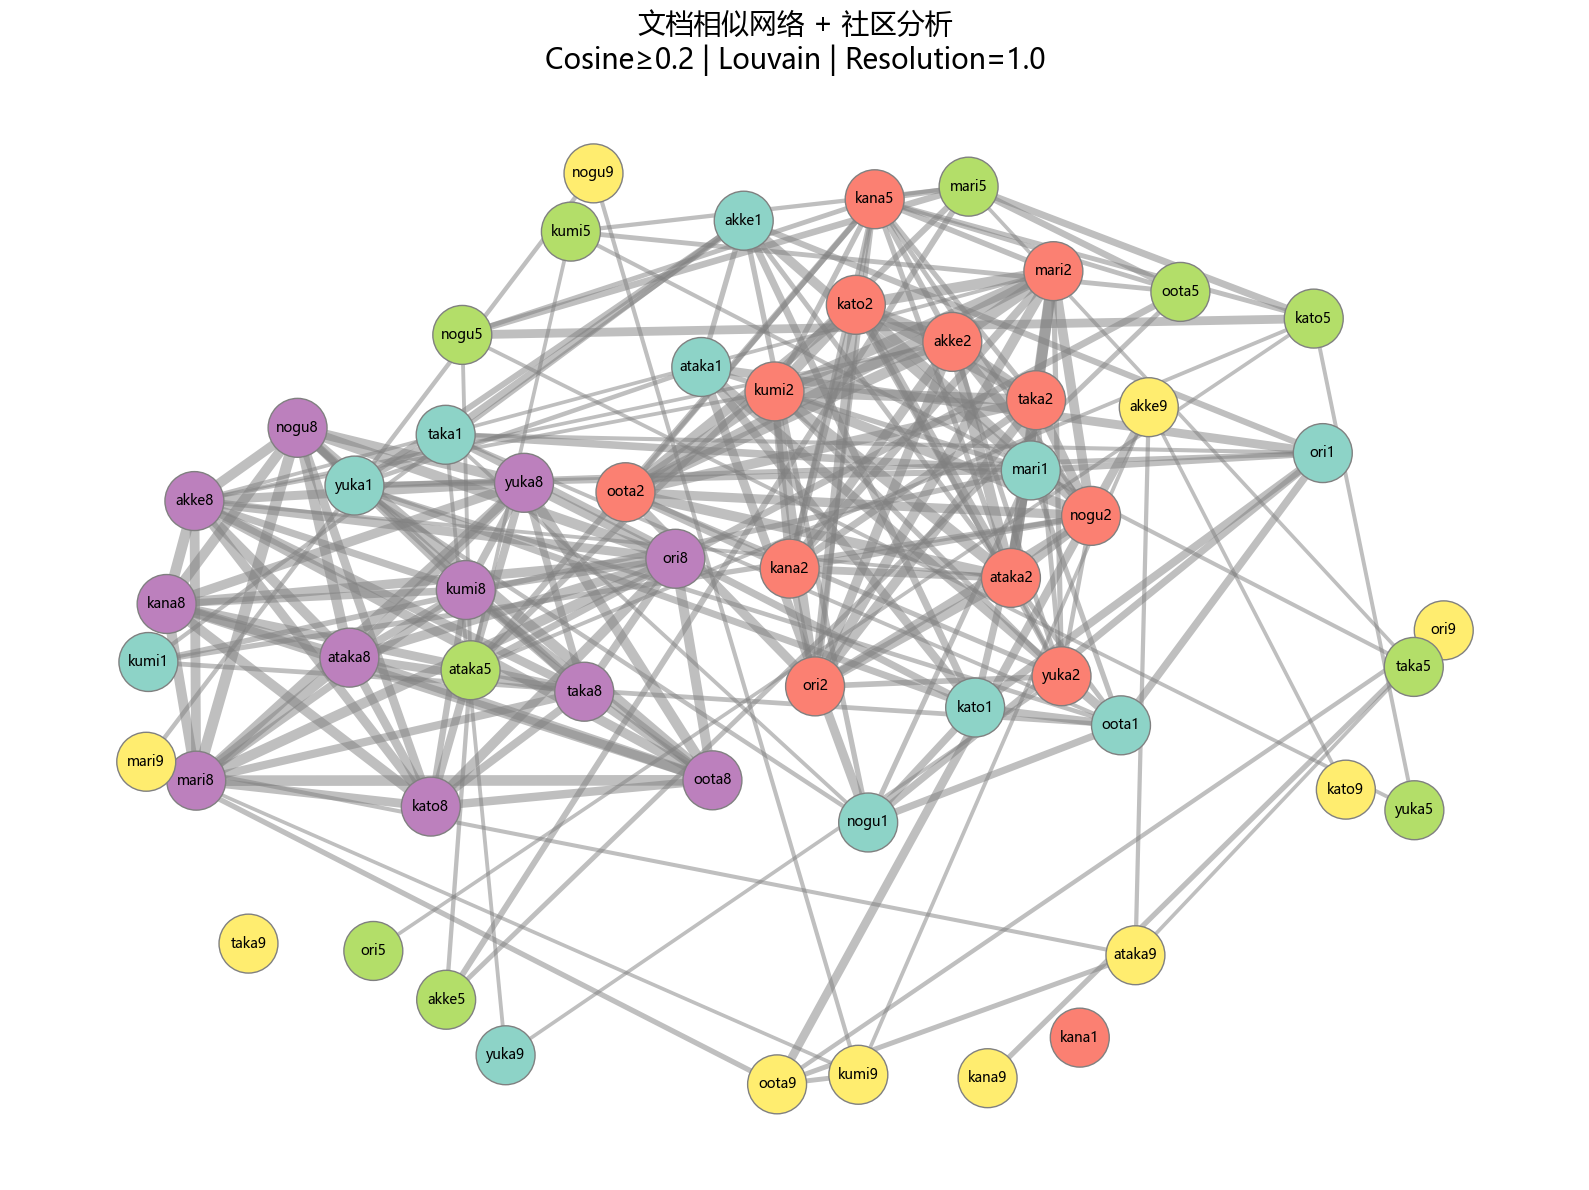


跨社区共享关键词数： 12
共享关键词： 家庭 / 父母 / 关系 / 社会 / 老家 / 原因 / 妈妈 / 定义 / 心情 / 朋友 / 汽车 / 事故
社区中心基本半径： 14.0
社区半径自动补偿系数： 0.8
实际社区中心分布半径： 17.713

图布局信息：
社区环半径： 17.71
最大社区圆真实半径： 4.64
社区圆外缘到独有关键词距离： 1.8
共享关键词数： 12
共享关键词最外环半径： 27.23

关键词节点权重： 相对TF
关键词权重范围： 0.004918 ～ 0.225022
关键词节点大小范围： 450 ～ 3000

✅ 社区－文档－关键词网络图保存：
C:\temp\文档相似网络结果\社区_文档_特征关键词网络.png


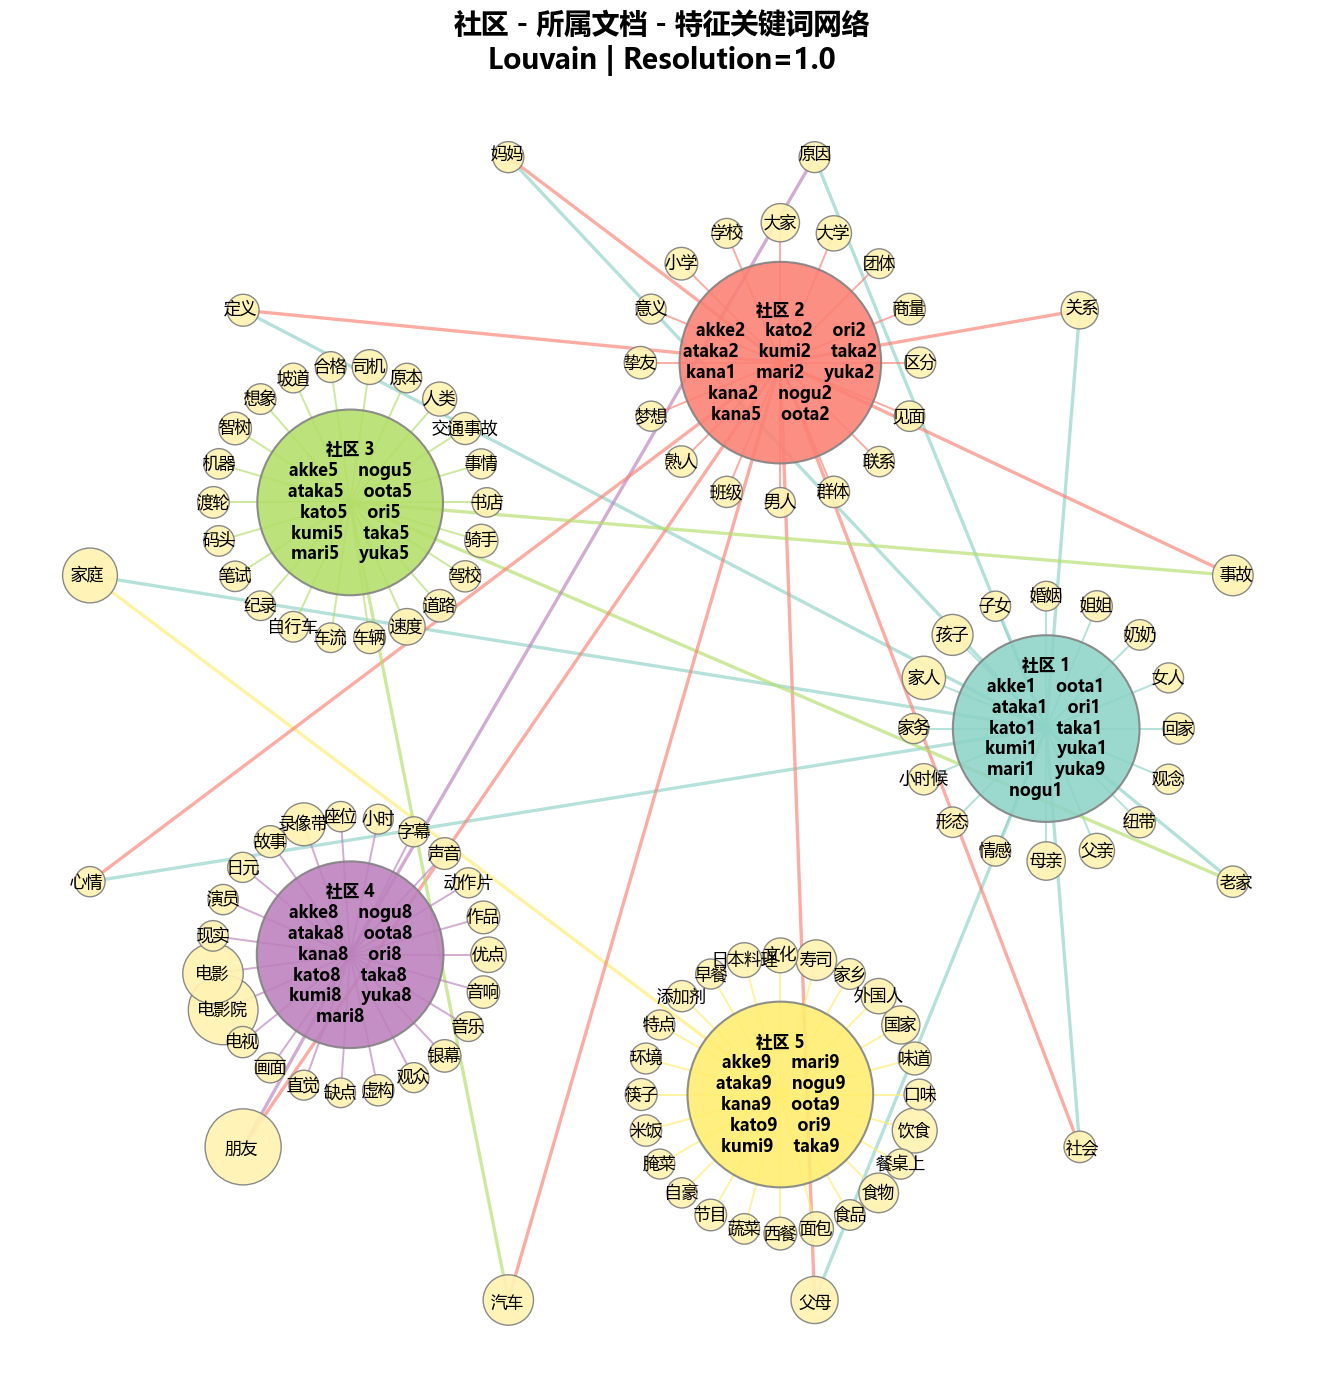


✅ 分析完成
相对TF矩阵：
C:\temp\文档相似网络结果\相对TF矩阵.csv

TF-IDF矩阵：
C:\temp\文档相似网络结果\TF-IDF矩阵.csv

文档相似网络图：
C:\temp\文档相似网络结果\文档相似网络_社区分析.png

社区－文档－特征关键词网络图：
C:\temp\文档相似网络结果\社区_文档_特征关键词网络.png

当前分析特征量：
相对TF

跨社区共享关键词CSV：
C:\temp\文档相似网络结果\跨社区共享关键词.csv

社区关键词权重CSV：
C:\temp\文档相似网络结果\社区关键词权重.csv

文档社区结果：
C:\temp\文档相似网络结果\文档社区分析结果.csv

社区特征关键词：
C:\temp\文档相似网络结果\社区特征关键词.csv

文档相似关系：
C:\temp\文档相似网络结果\文档相似关系.csv

完整相似度矩阵：
C:\temp\文档相似网络结果\文档相似度矩阵.csv

相似度方法：
余弦相似度

社区/聚类方法：
Louvain

Louvain resolution：
1.0

最终社区数：
5


In [1]:
# -*- coding: utf-8 -*-

"""
文档相似网络 + 社区分析 + 社区特征关键词
相对TF版・社区关键词网络追加版

新增图：
- 大型“社区节点”中显示该社区所属文档名
- 社区外侧显示该社区的特征关键词
- 社区节点与关键词节点用边连接
"""

import os
import re
import math
import jieba
import jieba.posseg as pseg
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. 核心配置区
# ============================================================

INPUT_FOLDER_PATH = (
    r"C:\Desktop"
    r"\讲座课件\zhuowen\network_text"
)

OUTPUT_DIR = r"C:\temp\文档相似网络结果"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. 分析参数
# ============================================================

# ------------------------------------------------------------
# 文档相似度 / 距离计算方法
# ------------------------------------------------------------
#
# "cosine"
#   → 余弦相似度（越大越相似）
#
# "hellinger"
#   → Hellinger距离（越小越相似）
#
SIMILARITY_METHOD = "cosine"


# ------------------------------------------------------------
# 余弦相似度阈值
# ------------------------------------------------------------
#
# 只有：
# cosine similarity >= COSINE_SIMILARITY_THRESHOLD
# 才建立文档之间的边。
#
COSINE_SIMILARITY_THRESHOLD = 0.20


# ------------------------------------------------------------
# Hellinger 距离阈值
# ------------------------------------------------------------
#
# Hellinger 距离越小越相似。
#
# 两种模式：
#
# "auto"
#   → 根据当前全部文档对的 Hellinger 距离分布，
#      自动取较小距离的一定百分比作为网络边。
#
# "manual"
#   → 使用 HELLINGER_DISTANCE_THRESHOLD 手动指定。
#
# 推荐先使用 "auto"。
#
HELLINGER_THRESHOLD_MODE = "auto"


# 手动模式时使用：
HELLINGER_DISTANCE_THRESHOLD = 0.45


# 自动模式时使用：
#
# 例如 25 表示：
# 将全部文档对中 Hellinger 距离最小的约25%作为候选边。
#
# 数值越小 → 网络越稀疏
# 数值越大 → 网络越密集
#
HELLINGER_AUTO_PERCENTILE = 25


# ------------------------------------------------------------
# Louvain 社区大小控制
# ------------------------------------------------------------
#
# 数值越小：
#   社区通常更大、数量更少
#
# 数值越大：
#   社区通常更小、数量更多
#
COMMUNITY_RESOLUTION = 1.0


# ------------------------------------------------------------
# Louvain 分割后允许的最小社区文档数
# ------------------------------------------------------------
#
# 1 = 不进行最小社区处理
# 3 = 小于3篇文档的社区会合并到最相似的其他社区
#
MIN_COMMUNITY_SIZE = 3
# 说明：Louvain 后会强制执行这个最小规模。
# 若小社区与其他社区没有阈值边，也会依据完整相似度矩阵
# 合并到平均相似度最高的社区。


# ------------------------------------------------------------
# 用户指定目标社区数
# ------------------------------------------------------------
#
# None = 不指定社区数，直接使用 COMMUNITY_RESOLUTION
#
# 例如：
# TARGET_COMMUNITY_COUNT = 5
#
# 程序会自动搜索 resolution，
# 尽量得到指定的社区数。
#
TARGET_COMMUNITY_COUNT = None


# ------------------------------------------------------------
# 指定社区数时，自动搜索 resolution 的范围
# ------------------------------------------------------------

AUTO_RESOLUTION_MIN = 0.20
AUTO_RESOLUTION_MAX = 3.00
AUTO_RESOLUTION_STEPS = 60


# 最小词长度
MIN_WORD_LEN = 2


# ============================================================
# ★ 分析特征量的选择
# ============================================================
#
# 重要说明：
# 本程序中的 TF-IDF 并不是“绝对词频 × IDF”。
# TF 部分使用已经按文档长度归一化的“相对词频”：
#
#   relative_tf = 该词出现次数 / 该文档分析词总数
#   tfidf       = relative_tf * idf
#
# 因此，长文档不会仅仅因为总词数更多而使所有 TF 值整体变大。
# 这一设计特别适合长度不同的作文、访谈、自由记述等文本比较。
#
FEATURE_MODE = "relative_tf"
#   → 权重 = 社区内该关键词的平均相对频率
# FEATURE_MODE = "tfidf"
#   → 权重 = 社区内该关键词的平均“相对TF × IDF”


# ============================================================
# ★ 文档分类 / 社区分析方法
# ============================================================
#
# "louvain"
#   → 文档相似网络 + Louvain 社区发现
#
# "kmeans_euclidean"
#   → 相对频率向量直接投入标准 K-means
#   → 使用 Euclidean 距离
#
# "kmeans_hellinger"
#   → sqrt(相对频率) 后投入 K-means
#   → 与 Hellinger 距离相对应
#
COMMUNITY_METHOD = "louvain"


# ============================================================
# ★ K-means 参数
# ============================================================
#
# "manual"
#   → 使用 KMEANS_N_CLUSTERS
#
# "auto"
#   → 在指定 K 范围内计算 Silhouette score，
#      自动采用得分最高的 K
#
KMEANS_K_MODE = "manual"

# manual 模式使用
KMEANS_N_CLUSTERS = 5

# auto 模式搜索范围
KMEANS_CHECK_K_MIN = 2
KMEANS_CHECK_K_MAX = 10
# 随机种子
KMEANS_RANDOM_STATE = 42
# K-means 重复初始化次数
KMEANS_N_INIT = 20


# ============================================================
# 3. 特征关键词数量
# ============================================================

# CSV / Notebook 中每个社区保存和显示的关键词数量
TOP_KEYWORDS = 30

# ★ 新增：
# “社区－关键词网络图”中，每个社区外侧显示几个关键词
COMMUNITY_GRAPH_KEYWORDS = 25

# ============================================================
# ★ 关键词节点大小设置
# ============================================================
#
# 关键词节点大小按照“当前分析特征量”的权重自动变化。
#
# FEATURE_MODE = "relative_tf"
#   → 权重 = 社区内该关键词的平均相对频率
#
# FEATURE_MODE = "tfidf"
#   → 权重 = 社区内该关键词的平均 TF-IDF
#
# 权重越大，关键词节点越大。
#
# 下列两个参数只规定显示尺寸范围，
# 不改变关键词权重本身。
KEYWORD_NODE_SIZE_MIN = 450
KEYWORD_NODE_SIZE_MAX = 3000

# ============================================================
# ★ 社区图布局设置
# ============================================================

# 一个社区内部的文档标签，每列最多显示多少个
DOC_LABELS_PER_COLUMN = 6

# ------------------------------------------------------------
# 社区中心的基本分布半径
# ------------------------------------------------------------
#
# 这个参数现在会“直接参与”最终社区中心半径的计算。
# 数值越大，各社区彼此越分散。
#
# 例如：
#   COMMUNITY_BASE_RADIUS = 9.0   → 较紧凑
#   COMMUNITY_BASE_RADIUS = 15.0  → 明显更分散
#
COMMUNITY_BASE_RADIUS = 14.0

# 根据“最大社区圆真实半径”自动追加的距离比例。
# 这样大社区出现时，社区中心之间会自动再拉开一点。
#
# 0.0 = 完全关闭自动补偿，此时最终半径基本由
#       COMMUNITY_BASE_RADIUS 决定。
# 0.8 = 推荐初始值。
COMMUNITY_RADIUS_AUTO_SCALE = 0.8

# ------------------------------------------------------------
# 社区圆外缘 → 独有关键词中心 的距离
# ------------------------------------------------------------
#
# 重要：关键词位置不再使用固定的“中心半径”。
# 程序会先估计每个社区圆的可视半径，再加上这个距离。
# 因此社区圆变大时，所属关键词会自动一起向外移动。
#
# 推荐：1.2 ～ 3.0
COMMUNITY_KEYWORD_GAP = 1.8

# ------------------------------------------------------------
# 社区圆半径（数据坐标单位）
# ------------------------------------------------------------
#
# 重要修正：
# 社区圆不再用 NetworkX 的 node_size（points^2）来画。
# 现在直接用 Matplotlib Circle，以“数据坐标半径”绘制。
#
# 因此：
#   独有关键词半径 = 社区圆真实半径 + COMMUNITY_KEYWORD_GAP
#
# 社区圆变大时，关键词会严格同步向外移动。
#
COMMUNITY_CIRCLE_RADIUS_BASE = 3.5
COMMUNITY_CIRCLE_RADIUS_DOC_SCALE = 0.15
COMMUNITY_CIRCLE_RADIUS_COLUMN_SCALE = 0.30

# 独有关键词很多时，关键词环自动增加的额外距离
LOCAL_KEYWORD_DENSITY_GROWTH = 0.055

# 共享关键词最外圈比所有“社区+独有关键词”再向外多少
SHARED_OUTER_RING_GAP = 2.2

# 共享关键词很多时，最外圈自动扩大的速度
SHARED_RING_GROWTH = 0.22

# 共享关键词标签相对节点再向外移动多少
SHARED_LABEL_OFFSET = 0.15

# 关键词的大小指定
KEYWORD_LABEL_SIZE = 12

# ============================================================
# 4. 中文字体
# ============================================================

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei"
]

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 5. 停用词
# ============================================================

STOPWORDS = set(
    """
    的 了 是 在 和 与 及 或 而 也 都 就 利卡 真纪 所以 时候 时间 为了
    有 一个 一种 这个 那个 这些 那些 地方 世界 有点 无法 结果 问题
    我 你 他 她 它 我们 他们 方式 情况 人们 感觉 经历 理由 消失 意识 对方 全国
    为 被 把 对 从 到 中 上 下
    很 更 最 还 又 已经 可以 进行
    """.split()
)

# ============================================================
# 6. 词性过滤
# ============================================================
#
# 只保留下面这些词性。
#
# n  = 普通名词
# nr = 人名
# ns = 地名
# nt = 机构团体名
# nz = 其他专名
# v  = 动词
# vn = 名动词
# a  = 形容词
# an = 名形词
# m  = 数词
#
# 教学时可以直接在这里增加或删除词性。
# ============================================================

KEEP_FLAGS = {
    "n",
    """
    "nr",
    "ns",
    "nt",
    "nz",
    "v",
    "vn",
    "a",
    "an",
    "m"
    """
}

# ============================================================
# 6. 分词
# ============================================================

def tokenize(text):
    """
    中文分词 + 停用词过滤 + 词长过滤 + 词性过滤
    """

    result = []

    for word, flag in pseg.cut(text):

        word = word.strip()

        # 最小词长度
        if len(word) < MIN_WORD_LEN:
            continue

        # 停用词
        if word in STOPWORDS:
            continue

        # 词性过滤
        if flag not in KEEP_FLAGS:
            continue

        # 纯数字
        if re.fullmatch(
            r"\d+",
            word
        ):
            continue

        # 纯符号
        if re.fullmatch(
            r"[\W_]+",
            word
        ):
            continue

        result.append(
            word
        )

    return result


# ============================================================
# 7. 读取全部 TXT
# ============================================================

def load_documents():
    """读取指定文件夹内全部 TXT 文档。"""

    if not os.path.isdir(INPUT_FOLDER_PATH):
        raise FileNotFoundError(
            "找不到输入文件夹：\n"
            + INPUT_FOLDER_PATH
        )

    filenames = []
    documents = []

    for filename in sorted(
        os.listdir(INPUT_FOLDER_PATH)
    ):
        if not filename.lower().endswith(".txt"):
            continue

        file_path = os.path.join(
            INPUT_FOLDER_PATH,
            filename
        )

        text_data = None

        for enc in (
            "utf-8",
            "utf-8-sig",
            "gbk"
        ):
            try:
                with open(
                    file_path,
                    "r",
                    encoding=enc
                ) as f:
                    text_data = f.read()
                break
            except UnicodeDecodeError:
                continue

        if text_data is None:
            print(
                "⚠️ 无法读取，跳过：",
                filename
            )
            continue

        filenames.append(
            os.path.splitext(filename)[0]
        )
        documents.append(
            text_data
        )

    print(
        "\n读取文档数：",
        len(documents)
    )

    return filenames, documents


# ============================================================
# 8. 读取文档
# ============================================================

filenames, documents = load_documents()

if len(documents) < 2:
    raise ValueError(
        "成功读取的文档少于2个，无法建立文档相似网络。"
    )

print(
    "\n成功读取文档数：",
    len(documents)
)


# ============================================================
# 9. 分词
# ============================================================

tokenized_documents = []

for text in documents:

    words = tokenize(
        text
    )

    tokenized_documents.append(
        " ".join(words)
    )


# ============================================================
# 10. 词频矩阵
# ============================================================

count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None
)

count_matrix = (
    count_vectorizer
    .fit_transform(
        tokenized_documents
    )
)

feature_words = (
    count_vectorizer
    .get_feature_names_out()
)

print(
    "词汇数：",
    len(feature_words)
)


# ============================================================
# 11. 相对 TF
#
# 本程序不用绝对词频作为 TF，而使用相对词频：
#
#   relative_tf(t, d)
#       = count(t, d) / 该文档中全部分析词的总数
#
# 每篇文档的相对TF之和约等于1。
# 这样可以降低文档长度差异对后续比较的直接影响。
# ============================================================

document_word_counts = np.asarray(
    count_matrix.sum(
        axis=1
    )
).ravel()

document_word_counts[
    document_word_counts == 0
] = 1

relative_tf_matrix = (
    count_matrix
    .multiply(
        1
        /
        document_word_counts[
            :,
            None
        ]
    )
    .tocsr()
)


# ============================================================
# 12. IDF
# ============================================================

N = len(documents)

document_frequency = np.asarray(
    (
        count_matrix
        >
        0
    )
    .sum(
        axis=0
    )
).ravel()

idf = (
    np.log(
        (1 + N)
        /
        (
            1
            +
            document_frequency
        )
    )
    +
    1
)


# ============================================================
# 13. TF-IDF
#
# 重要：这里的 TF 是“相对 TF”，不是绝对出现次数。
#
#   TF-IDF(t, d) = relative_tf(t, d) * IDF(t)
#
# 因此，TF-IDF 已经先按文档长度进行了归一化，
# 再通过 IDF 提高具有文档区分能力的词的权重。
# ============================================================

tfidf_matrix = (
    relative_tf_matrix
    .multiply(
        idf
    )
    .tocsr()
)

print(
    "TF-IDF矩阵：",
    tfidf_matrix.shape
)


# ============================================================
# 14. 保存相对 TF 矩阵
# ============================================================

relative_tf_df = pd.DataFrame(
    relative_tf_matrix.toarray(),
    index=filenames,
    columns=feature_words
)

relative_tf_csv_path = os.path.join(
    OUTPUT_DIR,
    "相对TF矩阵.csv"
)

relative_tf_df.to_csv(
    relative_tf_csv_path,
    encoding="utf-8-sig"
)


# ============================================================
# 15. 保存 TF-IDF 矩阵
# ============================================================

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=filenames,
    columns=feature_words
)

tfidf_csv_path = os.path.join(
    OUTPUT_DIR,
    "TF-IDF矩阵.csv"
)

tfidf_df.to_csv(
    tfidf_csv_path,
    encoding="utf-8-sig"
)


# ============================================================
# 16. 分析特征量选择
# ============================================================

if FEATURE_MODE == "tfidf":
    analysis_matrix = tfidf_matrix
    feature_mode_name = "TF-IDF（相对TF × IDF）"

elif FEATURE_MODE == "relative_tf":
    analysis_matrix = relative_tf_matrix
    feature_mode_name = "相对TF"

else:
    raise ValueError(
        'FEATURE_MODE 只能设置为 "tfidf" 或 "relative_tf"'
    )

print("\n分析特征量：", feature_mode_name)


# ============================================================
# 17. 文档相似度
# ============================================================
#
# cosine：
#   直接计算余弦相似度
#
# hellinger：
#   Hellinger 距离要求输入是概率分布。
#
#   relative_tf：
#       本身已经是相对频率分布。
#
#   tfidf：
#       先将每篇文档的 TF-IDF 向量归一化，
#       使每行总和 = 1，
#       再计算 Hellinger 距离。
#
# Hellinger 距离范围：0 ～ 1
# 距离越小越相似。
#
# 为了和现有网络阈值统一，
# 网络中使用：
#
# Hellinger相似度 = 1 - Hellinger距离
# ============================================================

hellinger_distance_matrix = None


if SIMILARITY_METHOD == "cosine":

    similarity_matrix = cosine_similarity(
        analysis_matrix
    )

    similarity_method_name = "余弦相似度"


elif SIMILARITY_METHOD == "hellinger":

    dense_matrix = np.asarray(
        analysis_matrix.toarray(),
        dtype=float
    )

    row_sums = dense_matrix.sum(
        axis=1,
        keepdims=True
    )

    row_sums[
        row_sums == 0
    ] = 1.0

    probability_matrix = (
        dense_matrix
        /
        row_sums
    )

    sqrt_probability_matrix = np.sqrt(
        probability_matrix
    )

    hellinger_distance_matrix = (
        euclidean_distances(
            sqrt_probability_matrix
        )
        /
        np.sqrt(
            2.0
        )
    )

    # 数值误差修正
    hellinger_distance_matrix = np.clip(
        hellinger_distance_matrix,
        0.0,
        1.0
    )

    # Louvain 的边权仍使用“相似度”，
    # 因而边权定义为 1 - Hellinger distance。
    similarity_matrix = (
        1.0
        -
        hellinger_distance_matrix
    )

    similarity_method_name = (
        "Hellinger距离"
    )


    # --------------------------------------------------------
    # Hellinger 有效阈值
    # --------------------------------------------------------

    pair_indices_for_threshold = np.triu_indices(
        len(
            filenames
        ),
        k=1
    )

    pair_distances_for_threshold = (
        hellinger_distance_matrix[
            pair_indices_for_threshold
        ]
    )


    if HELLINGER_THRESHOLD_MODE == "auto":

        effective_hellinger_threshold = float(
            np.percentile(
                pair_distances_for_threshold,
                HELLINGER_AUTO_PERCENTILE
            )
        )


    elif HELLINGER_THRESHOLD_MODE == "manual":

        effective_hellinger_threshold = float(
            HELLINGER_DISTANCE_THRESHOLD
        )


    else:

        raise ValueError(
            'HELLINGER_THRESHOLD_MODE 只能设置为 '
            '"auto" 或 "manual"'
        )


else:

    raise ValueError(
        'SIMILARITY_METHOD 只能设置为 '
        '"cosine" 或 "hellinger"'
    )


print(
    "文档相似度方法：",
    similarity_method_name
)


# ------------------------------------------------------------
# 距离 / 相似度分布诊断
# ------------------------------------------------------------

upper_triangle = np.triu_indices(
    len(
        filenames
    ),
    k=1
)


if SIMILARITY_METHOD == "cosine":

    pair_values = similarity_matrix[
        upper_triangle
    ]

    print(
        "余弦相似度分布 "
        "(min / median / max)：",
        round(
            float(
                np.min(
                    pair_values
                )
            ),
            4
        ),
        "/",
        round(
            float(
                np.median(
                    pair_values
                )
            ),
            4
        ),
        "/",
        round(
            float(
                np.max(
                    pair_values
                )
            ),
            4
        )
    )


else:

    pair_values = hellinger_distance_matrix[
        upper_triangle
    ]

    print(
        "Hellinger距离分布 "
        "(min / median / max)：",
        round(
            float(
                np.min(
                    pair_values
                )
            ),
            4
        ),
        "/",
        round(
            float(
                np.median(
                    pair_values
                )
            ),
            4
        ),
        "/",
        round(
            float(
                np.max(
                    pair_values
                )
            ),
            4
        )
    )


# ============================================================
# 17. 建立文档相似网络
# ============================================================

G = nx.Graph()

for filename in filenames:
    G.add_node(
        filename
    )

for i in range(
    len(filenames)
):

    for j in range(
        i + 1,
        len(filenames)
    ):

        similarity = float(
            similarity_matrix[
                i,
                j
            ]
        )

        # --------------------------------------------
        # 根据选择的方法决定是否建立边
        # --------------------------------------------

        if SIMILARITY_METHOD == "cosine":

            keep_edge = (
                similarity
                >=
                COSINE_SIMILARITY_THRESHOLD
            )

            edge_distance = None


        else:

            distance = float(
                hellinger_distance_matrix[
                    i,
                    j
                ]
            )

            keep_edge = (
                distance
                <=
                effective_hellinger_threshold
            )

            edge_distance = distance


        if keep_edge:

            G.add_edge(
                filenames[i],
                filenames[j],

                # Louvain 使用“相似性”作为权重
                weight=similarity,

                # Hellinger 模式时同时保存距离
                distance=edge_distance
            )


print(
    "\n"
    +
    "=" * 60
)

print(
    "文档相似网络"
)

print(
    "=" * 60
)

print(
    "节点数：",
    G.number_of_nodes()
)

print(
    "边数：",
    G.number_of_edges()
)


# ------------------------------------------------------------
# 网络有效性检查
# ------------------------------------------------------------

if G.number_of_edges() == 0:

    raise ValueError(
        "当前参数下文档网络没有任何边。\n"
        "这不是社区分析结果，而是相似度阈值过严格。\n"
        "如果使用 Hellinger，建议：\n"
        '1. 设置 HELLINGER_THRESHOLD_MODE = "auto"；或\n'
        "2. 手动提高 HELLINGER_DISTANCE_THRESHOLD。"
    )

print(
    "相似度方法：",
    similarity_method_name
)

if SIMILARITY_METHOD == "cosine":

    print(
        "余弦相似度阈值：",
        COSINE_SIMILARITY_THRESHOLD
    )

else:

    print(
        "Hellinger阈值模式：",
        HELLINGER_THRESHOLD_MODE
    )

    print(
        "Hellinger有效距离阈值：",
        round(
            effective_hellinger_threshold,
            4
        )
    )

    if HELLINGER_THRESHOLD_MODE == "auto":

        print(
            "自动阈值百分位：",
            HELLINGER_AUTO_PERCENTILE,
            "%"
        )


# ============================================================
# 18. 文档分类 / 社区分析
# ============================================================
#
# 支持三种方法：
# 1. Louvain
# 2. 标准 K-means（相对频率 + Euclidean）
# 3. Hellinger K-means（sqrt(相对频率) + Euclidean K-means）
# ============================================================


def average_similarity_between_groups(
    group_a,
    group_b,
    similarity_matrix,
    filename_to_index
):
    """两个社区之间的平均文档相似度。"""

    values = []

    for doc_a in group_a:
        i = filename_to_index[doc_a]

        for doc_b in group_b:
            j = filename_to_index[doc_b]
            values.append(
                similarity_matrix[i, j]
            )

    if len(values) == 0:
        return 0.0

    return float(
        np.mean(values)
    )


def merge_small_communities(
    communities,
    graph,
    full_similarity_matrix,
    filenames,
    min_size
):
    """
    Louvain 分割后强制执行 MIN_COMMUNITY_SIZE。

    优先依据网络中实际边合并；
    若没有阈值边，则使用完整相似度矩阵寻找最接近社区。
    """

    communities = [
        set(c)
        for c in communities
    ]

    if min_size <= 1:
        return communities

    if len(filenames) < min_size:
        print(
            "⚠️ 文档总数小于 MIN_COMMUNITY_SIZE，"
            "无法满足最小社区规模。"
        )
        return communities

    filename_to_index = {
        filename: i
        for i, filename in enumerate(filenames)
    }

    def full_average_similarity(group_a, group_b):
        return average_similarity_between_groups(
            group_a,
            group_b,
            full_similarity_matrix,
            filename_to_index
        )

    while True:
        small_indices = [
            i
            for i, c in enumerate(communities)
            if len(c) < min_size
        ]

        if len(small_indices) == 0 or len(communities) <= 1:
            break

        source_index = min(
            small_indices,
            key=lambda i: len(communities[i])
        )

        source_group = communities[source_index]

        candidate_indices = [
            i
            for i, c in enumerate(communities)
            if i != source_index
        ]

        best_target = None
        best_score = -1.0

        # 第一优先：实际网络边
        for target_index in candidate_indices:
            target_group = communities[target_index]
            weights = []

            for a in source_group:
                for b in target_group:
                    if graph.has_edge(a, b):
                        weights.append(
                            graph[a][b].get("weight", 0.0)
                        )

            if len(weights) > 0:
                score = float(np.mean(weights))
                if score > best_score:
                    best_score = score
                    best_target = target_index

        # 第二优先：完整相似度矩阵
        used_fallback = False

        if best_target is None:
            used_fallback = True

            for target_index in candidate_indices:
                score = full_average_similarity(
                    source_group,
                    communities[target_index]
                )

                if score > best_score:
                    best_score = score
                    best_target = target_index

        if best_target is None:
            break

        source_size = len(source_group)
        target_size = len(communities[best_target])

        communities[best_target] = (
            communities[best_target]
            |
            source_group
        )

        communities.pop(source_index)

        if used_fallback:
            print(
                "⚠️ 小社区无阈值边，使用完整相似度矩阵强制合并：",
                "原社区大小=", source_size,
                "→ 目标社区原大小=", target_size,
                "，平均相似度=", round(best_score, 4)
            )

    return communities


def run_louvain(graph, resolution_value):
    """运行 Louvain，并执行最小社区规模后处理。"""

    result = nx.community.louvain_communities(
        graph,
        weight="weight",
        resolution=resolution_value,
        seed=42
    )

    result = merge_small_communities(
        result,
        graph,
        similarity_matrix,
        filenames,
        MIN_COMMUNITY_SIZE
    )

    result = sorted(
        result,
        key=lambda community: min(
            filenames.index(doc)
            for doc in community
        )
    )

    return result


def prepare_kmeans_matrix(mode):
    """准备 K-means 输入矩阵。"""

    base = np.asarray(
        relative_tf_matrix.toarray(),
        dtype=float
    )

    if mode == "kmeans_euclidean":
        return base, "K-means（相对频率 + Euclidean）"

    if mode == "kmeans_hellinger":
        # Hellinger:
        # H(P,Q) = 1/sqrt(2) * ||sqrt(P)-sqrt(Q)||_2
        # 共同常数 1/sqrt(2) 不影响 K-means 的分配。
        return np.sqrt(base), "K-means（sqrt相对频率 / Hellinger）"

    raise ValueError(
        'K-means mode 必须是 "kmeans_euclidean" '
        '或 "kmeans_hellinger"'
    )


def evaluate_kmeans_k(X, k_min, k_max):
    """计算不同 K 的 Silhouette score。"""

    rows = []
    n_samples = X.shape[0]

    valid_min = max(2, int(k_min))
    valid_max = min(int(k_max), n_samples - 1)

    if valid_max < valid_min:
        return pd.DataFrame(
            columns=["K", "Silhouette"]
        )

    for k in range(valid_min, valid_max + 1):

        model = KMeans(
            n_clusters=k,
            random_state=KMEANS_RANDOM_STATE,
            n_init=KMEANS_N_INIT
        )

        labels = model.fit_predict(X)

        # 理论上 KMeans 会产生 k 个簇，仍做安全检查。
        if len(set(labels)) < 2:
            continue

        score = silhouette_score(
            X,
            labels,
            metric="euclidean"
        )

        rows.append({
            "K": k,
            "Silhouette": float(score)
        })

    return pd.DataFrame(rows)


selected_resolution = None
silhouette_df = pd.DataFrame(
    columns=["K", "Silhouette"]
)
silhouette_csv_path = None
selected_k = None


# ------------------------------------------------------------
# 18-1. Louvain
# ------------------------------------------------------------

if COMMUNITY_METHOD == "louvain":

    community_method_name = "Louvain"

    if TARGET_COMMUNITY_COUNT is None:

        selected_resolution = COMMUNITY_RESOLUTION
        communities = run_louvain(
            G,
            selected_resolution
        )

    else:

        if TARGET_COMMUNITY_COUNT < 1:
            raise ValueError(
                "TARGET_COMMUNITY_COUNT 必须 >= 1"
            )

        if MIN_COMMUNITY_SIZE > 1:
            max_possible_communities = (
                len(filenames)
                //
                MIN_COMMUNITY_SIZE
            )

            if TARGET_COMMUNITY_COUNT > max_possible_communities:
                raise ValueError(
                    "TARGET_COMMUNITY_COUNT 与 MIN_COMMUNITY_SIZE "
                    "的组合无法实现。\n"
                    "当前文档数：" + str(len(filenames))
                    + "\nMIN_COMMUNITY_SIZE：" + str(MIN_COMMUNITY_SIZE)
                    + "\n理论上最多社区数：" + str(max_possible_communities)
                )

        resolution_candidates = np.linspace(
            AUTO_RESOLUTION_MIN,
            AUTO_RESOLUTION_MAX,
            AUTO_RESOLUTION_STEPS
        )

        best_communities = None
        best_resolution = None
        best_difference = None
        best_resolution_distance = None

        for resolution_value in resolution_candidates:

            candidate_communities = run_louvain(
                G,
                float(resolution_value)
            )

            candidate_count = len(candidate_communities)
            difference = abs(
                candidate_count
                -
                TARGET_COMMUNITY_COUNT
            )

            resolution_distance = abs(
                float(resolution_value)
                -
                COMMUNITY_RESOLUTION
            )

            if (
                best_difference is None
                or difference < best_difference
                or (
                    difference == best_difference
                    and resolution_distance < best_resolution_distance
                )
            ):
                best_communities = candidate_communities
                best_resolution = float(resolution_value)
                best_difference = difference
                best_resolution_distance = resolution_distance

        communities = best_communities
        selected_resolution = best_resolution


# ------------------------------------------------------------
# 18-2. K-means
# ------------------------------------------------------------

elif COMMUNITY_METHOD in (
    "kmeans_euclidean",
    "kmeans_hellinger"
):

    X_kmeans, community_method_name = prepare_kmeans_matrix(
        COMMUNITY_METHOD
    )

    silhouette_df = evaluate_kmeans_k(
        X_kmeans,
        KMEANS_CHECK_K_MIN,
        KMEANS_CHECK_K_MAX
    )

    # Silhouette 结果始终保存，便于比较 K。
    silhouette_csv_path = os.path.join(
        OUTPUT_DIR,
        "KMeans_Silhouette评价.csv"
    )

    silhouette_df.to_csv(
        silhouette_csv_path,
        index=False,
        encoding="utf-8-sig"
    )

    if KMEANS_K_MODE == "manual":
        selected_k = int(KMEANS_N_CLUSTERS)

    elif KMEANS_K_MODE == "auto":

        if len(silhouette_df) == 0:
            raise ValueError(
                "无法计算 Silhouette。请检查 K 的范围和文档数量。"
            )

        best_row = silhouette_df.loc[
            silhouette_df["Silhouette"].idxmax()
        ]

        selected_k = int(best_row["K"])

    else:
        raise ValueError(
            'KMEANS_K_MODE 只能设置为 "manual" 或 "auto"'
        )

    if selected_k < 1:
        raise ValueError("K 必须 >= 1")

    if selected_k > len(filenames):
        raise ValueError(
            "K 不能大于文档数。"
        )

    kmeans_model = KMeans(
        n_clusters=selected_k,
        random_state=KMEANS_RANDOM_STATE,
        n_init=KMEANS_N_INIT
    )

    kmeans_labels = kmeans_model.fit_predict(
        X_kmeans
    )

    # 按文档顺序构造社区，编号从 1 开始。
    raw_communities = []

    for cluster_id in sorted(set(kmeans_labels)):
        docs = {
            filenames[i]
            for i, label in enumerate(kmeans_labels)
            if label == cluster_id
        }
        raw_communities.append(docs)

    raw_communities = sorted(
        raw_communities,
        key=lambda community: min(
            filenames.index(doc)
            for doc in community
        )
    )

    communities = raw_communities


else:
    raise ValueError(
        'COMMUNITY_METHOD 只能设置为 '
        '"louvain", "kmeans_euclidean", "kmeans_hellinger"'
    )


# ------------------------------------------------------------
# 18-3. community_map
# ------------------------------------------------------------

community_map = {}

for community_id, community in enumerate(
    communities,
    start=1
):
    for document in community:
        community_map[document] = community_id


print("\n" + "=" * 60)
print("文档分类 / 社区分析")
print("=" * 60)
print("方法：", community_method_name)
print("最终社区数：", len(communities))
print(
    "各社区文档数：",
    [len(c) for c in communities]
)

if COMMUNITY_METHOD == "louvain":
    print(
        "使用的 resolution：",
        round(selected_resolution, 4)
    )
    print(
        "MIN_COMMUNITY_SIZE：",
        MIN_COMMUNITY_SIZE
    )
    print(
        "目标社区数：",
        TARGET_COMMUNITY_COUNT
    )

    if (
        TARGET_COMMUNITY_COUNT is not None
        and len(communities) != TARGET_COMMUNITY_COUNT
    ):
        print(
            "⚠️ 指定范围内没有得到完全相同的社区数；"
            "已选择最接近目标的 resolution。"
        )

else:
    print("KMEANS_K_MODE：", KMEANS_K_MODE)
    print("采用 K：", selected_k)

    if len(silhouette_df) > 0:
        print("\nSilhouette 评价：")
        print(
            silhouette_df.to_string(
                index=False,
                float_format=lambda x: f"{x:.4f}"
            )
        )

        best_row = silhouette_df.loc[
            silhouette_df["Silhouette"].idxmax()
        ]

        print(
            "Silhouette 最优 K：",
            int(best_row["K"]),
            "，score=",
            round(float(best_row["Silhouette"]), 4)
        )

# ============================================================
# 19. 社区特征关键词
# ============================================================

community_keywords = {}

# 同时保留关键词TF-IDF值，后面的图可以用
community_keyword_scores = {}

for community_id, community in enumerate(
    communities,
    start=1
):

    doc_indices = [
        filenames.index(
            doc
        )
        for doc in community
    ]

    mean_feature = np.asarray(
        analysis_matrix[
            doc_indices
        ]
        .mean(
            axis=0
        )
    ).ravel()

    top_indices = (
        mean_feature
        .argsort()[::-1]
    )

    keywords = []
    keyword_scores = []

    for index in top_indices:

        if mean_feature[
            index
        ] <= 0:
            continue

        keywords.append(
            feature_words[
                index
            ]
        )

        keyword_scores.append(
            float(
                mean_feature[
                    index
                ]
            )
        )

        if len(
            keywords
        ) >= TOP_KEYWORDS:
            break

    community_keywords[
        community_id
    ] = keywords

    community_keyword_scores[
        community_id
    ] = keyword_scores


# ============================================================
# 20. Notebook显示社区结果
# ============================================================

print(
    "\n"
    +
    "=" * 60
)

print(
    "社区分析结果"
)

print(
    "=" * 60
)

for community_id, community in enumerate(
    communities,
    start=1
):

    print(
        "\n【社区",
        community_id,
        "】"
    )

    print(
        "文档："
    )

    for document in sorted(
        community
    ):
        print(
            "  ",
            document
        )

    print(
        "特征关键词："
    )

    print(
        "  ",
        " / ".join(
            community_keywords[
                community_id
            ]
        )
    )


# ============================================================
# 21. 图1：原来的文档相似网络 + 社区分析
# ============================================================

pos = nx.spring_layout(
    G,
    weight="weight",
    seed=42,
    k=1.2
)

node_colors = [
    community_map[
        node
    ]
    for node in G.nodes()
]

edge_widths = [
    1
    +
    G[u][v]
    .get(
        "weight",
        0
    )
    *
    8
    for u, v in G.edges()
]

fig, ax = plt.subplots(
    figsize=(
        16,
        12
    )
)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_color=
        node_colors,
    cmap=
        plt.cm.Set3,
    node_size=
        1800,
    edgecolors=
        "gray"
)

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    width=
        edge_widths,
    alpha=
        0.5,
    edge_color=
        "gray"
)

nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    font_size= 10
)

if SIMILARITY_METHOD == "cosine":

    threshold_title = (
        "Cosine≥"
        +
        str(
            COSINE_SIMILARITY_THRESHOLD
        )
    )

else:

    threshold_title = (
        "Hellinger≤"
        +
        str(
            round(
                effective_hellinger_threshold,
                3
            )
        )
    )


if COMMUNITY_METHOD == "louvain":

    community_title = (
        "Louvain | Resolution="
        + str(round(selected_resolution, 3))
    )

else:

    community_title = (
        community_method_name
        + " | K="
        + str(selected_k)
    )


ax.set_title(
    "文档相似网络 + 社区分析"
    + "\n"
    + threshold_title
    + " | "
    + community_title,
    fontsize=20
)

ax.axis(
    "off"
)

fig.tight_layout()

image_path = os.path.join(
    OUTPUT_DIR,
    "文档相似网络_社区分析.png"
)

fig.savefig(
    image_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(
    "\n✅ 文档相似网络图保存："
)

print(
    image_path
)

plt.show()


# ============================================================
# 22. 社区－文档－特征关键词网络
#
# 同一个关键词只建立一个节点。
# 如果同一关键词属于多个社区，它会同时连接多个社区：
#
# 社区1 ── 关键词 ── 社区3
# ============================================================

community_keyword_G = nx.Graph()
graph_keywords_by_community = {}

for community_id, community in enumerate(
    communities,
    start=1
):

    community_node = "COMMUNITY_" + str(community_id)

    community_keyword_G.add_node(
        community_node,
        node_type="community",
        community_id=community_id
    )

    graph_keywords = community_keywords[
        community_id
    ][:COMMUNITY_GRAPH_KEYWORDS]

    graph_scores = community_keyword_scores[
        community_id
    ][:COMMUNITY_GRAPH_KEYWORDS]

    graph_keywords_by_community[
        community_id
    ] = graph_keywords

    for keyword, score in zip(
        graph_keywords,
        graph_scores
    ):

        # ★社区番号を入れないので共有語は同一ノードになる
        keyword_node = "KEYWORD_" + str(keyword)

        if not community_keyword_G.has_node(
            keyword_node
        ):
            community_keyword_G.add_node(
                keyword_node,
                node_type="keyword",
                label=keyword,
                communities=[],
                score_max=score
            )

        data = community_keyword_G.nodes[
            keyword_node
        ]

        if community_id not in data["communities"]:
            data["communities"].append(
                community_id
            )

        data["score_max"] = max(
            data.get("score_max", 0),
            score
        )

        community_keyword_G.add_edge(
            community_node,
            keyword_node,
            weight=score
        )


shared_keywords = []

for node, data in community_keyword_G.nodes(
    data=True
):
    if (
        data.get("node_type") == "keyword"
        and
        len(data.get("communities", [])) >= 2
    ):
        shared_keywords.append(
            data.get("label", node)
        )

print(
    "\n跨社区共享关键词数：",
    len(shared_keywords)
)

if shared_keywords:
    print(
        "共享关键词：",
        " / ".join(shared_keywords)
    )


# ============================================================
# 23. 新网络的节点位置
# ============================================================
#
# 三层结构：
# ① 社区节点
# ② 各社区独有关键词
# ③ 多社区共享关键词（最外圈）
#
# 重要改进：
# 独有关键词的位置 = 社区“可视半径” + COMMUNITY_KEYWORD_GAP。
# 因而社区节点由于文档数增加而变大时，关键词会同步向外移动，
# 不会被社区圆吞进去。
# ============================================================

community_keyword_pos = {}
community_count = len(communities)


def get_community_column_count(doc_count):
    return max(
        1,
        int(
            math.ceil(
                doc_count
                /
                DOC_LABELS_PER_COLUMN
            )
        )
    )


def get_community_circle_radius(doc_count):
    """
    返回社区圆在“数据坐标”中的真实半径。

    文档越多，圆越大；多列标签时也稍微增大。
    这个半径既用于真正绘制社区圆，也用于关键词位置计算，
    因而两者严格联动。
    """

    column_count = get_community_column_count(
        doc_count
    )

    return (
        COMMUNITY_CIRCLE_RADIUS_BASE
        +
        math.sqrt(
            max(
                doc_count,
                1
            )
        )
        *
        COMMUNITY_CIRCLE_RADIUS_DOC_SCALE
        +
        max(
            column_count - 1,
            0
        )
        *
        COMMUNITY_CIRCLE_RADIUS_COLUMN_SCALE
    )


community_visual_radius = {
    community_id: get_community_circle_radius(
        len(community)
    )
    for community_id, community in enumerate(
        communities,
        start=1
    )
}

max_community_visual_radius = max(
    community_visual_radius.values(),
    default=1.0
)

# 社区中心的最终分布半径。
#
# 以前这里使用 max(...)，因此当自动计算值已经大于
# COMMUNITY_BASE_RADIUS 时，把 9 改成 15 可能完全没有变化。
#
# 现在改为“用户基本半径 + 大社区自动补偿”：
#
#   COMMUNITY_RADIUS
#       = COMMUNITY_BASE_RADIUS
#         + max_community_visual_radius
#           * COMMUNITY_RADIUS_AUTO_SCALE
#
# 因此 COMMUNITY_BASE_RADIUS 的修改会直接反映到图上；
# 同时社区圆较大时仍然保留必要的自动间距。
COMMUNITY_RADIUS = (
    COMMUNITY_BASE_RADIUS
    +
    max_community_visual_radius
    *
    COMMUNITY_RADIUS_AUTO_SCALE
)

print(
    "社区中心基本半径：",
    COMMUNITY_BASE_RADIUS
)

print(
    "社区半径自动补偿系数：",
    COMMUNITY_RADIUS_AUTO_SCALE
)

print(
    "实际社区中心分布半径：",
    round(
        COMMUNITY_RADIUS,
        3
    )
)

community_centers = {}

for idx, community_id in enumerate(
    range(1, community_count + 1)
):

    angle = (
        2
        * math.pi
        * idx
        / max(community_count, 1)
    )

    center_x = COMMUNITY_RADIUS * math.cos(angle)
    center_y = COMMUNITY_RADIUS * math.sin(angle)

    community_centers[community_id] = (
        center_x,
        center_y
    )

    community_keyword_pos[
        "COMMUNITY_" + str(community_id)
    ] = (
        center_x,
        center_y
    )


# ------------------------------------------------------------
# 23-2. 区分共享词与独有词
# ------------------------------------------------------------

shared_keyword_nodes = []

single_keyword_nodes_by_community = {
    community_id: []
    for community_id in range(
        1,
        community_count + 1
    )
}

for node, data in community_keyword_G.nodes(
    data=True
):

    if data.get("node_type") != "keyword":
        continue

    related = data.get(
        "communities",
        []
    )

    if len(related) >= 2:
        shared_keyword_nodes.append(node)

    elif len(related) == 1:
        single_keyword_nodes_by_community[
            related[0]
        ].append(node)


# ------------------------------------------------------------
# 23-3. 独有关键词
# ------------------------------------------------------------

local_keyword_radius_by_community = {}

for community_id in range(
    1,
    community_count + 1
):

    nodes_here = sorted(
        single_keyword_nodes_by_community[
            community_id
        ],
        key=str
    )

    total = len(nodes_here)

    if total == 0:
        local_keyword_radius_by_community[
            community_id
        ] = (
            community_visual_radius[community_id]
            +
            COMMUNITY_KEYWORD_GAP
        )
        continue

    center_x, center_y = community_centers[
        community_id
    ]

    # 关键：社区越大，关键词环自动同步向外。
    local_radius = (
        community_visual_radius[
            community_id
        ]
        +
        COMMUNITY_KEYWORD_GAP
        +
        max(
            0,
            total - 18
        )
        *
        LOCAL_KEYWORD_DENSITY_GROWTH
    )

    local_keyword_radius_by_community[
        community_id
    ] = local_radius

    for idx, node in enumerate(nodes_here):

        angle = (
            2
            * math.pi
            * idx
            / total
        )

        community_keyword_pos[node] = (
            center_x
            +
            local_radius
            *
            math.cos(angle),

            center_y
            +
            local_radius
            *
            math.sin(angle)
        )


# ------------------------------------------------------------
# 23-4. 共享关键词：统一放在整张图最外圈
# ------------------------------------------------------------

shared_keyword_nodes = sorted(
    shared_keyword_nodes,
    key=lambda node: (
        -len(
            community_keyword_G.nodes[node].get(
                "communities",
                []
            )
        ),
        str(
            community_keyword_G.nodes[node].get(
                "label",
                node
            )
        )
    )
)

shared_count = len(shared_keyword_nodes)

max_local_radius = max(
    local_keyword_radius_by_community.values(),
    default=max_community_visual_radius + COMMUNITY_KEYWORD_GAP
)

SHARED_KEYWORD_RADIUS = (
    COMMUNITY_RADIUS
    +
    max_local_radius
    +
    SHARED_OUTER_RING_GAP
    +
    max(
        0,
        shared_count - 8
    )
    *
    SHARED_RING_GROWTH
)

for idx, node in enumerate(
    shared_keyword_nodes
):

    if shared_count == 1:
        angle = math.pi / 2
    else:
        angle = (
            2
            * math.pi
            * (idx + 0.5)
            / shared_count
        )

    community_keyword_pos[node] = (
        SHARED_KEYWORD_RADIUS
        * math.cos(angle),
        SHARED_KEYWORD_RADIUS
        * math.sin(angle)
    )


print("\n图布局信息：")
print("社区环半径：", round(COMMUNITY_RADIUS, 2))
print(
    "最大社区圆真实半径：",
    round(max_community_visual_radius, 2)
)
print(
    "社区圆外缘到独有关键词距离：",
    COMMUNITY_KEYWORD_GAP
)
print("共享关键词数：", shared_count)
print(
    "共享关键词最外环半径：",
    round(SHARED_KEYWORD_RADIUS, 2)
)

# ============================================================
# 24. 新增网络图的节点标签
# ============================================================

community_labels = {}

keyword_labels = {}


def make_multicolumn_document_label(
    community_id,
    document_names,
    max_rows=DOC_LABELS_PER_COLUMN
):
    """
    社区内文档名自动分成多列。

    例如：
    1～10篇   → 1列
    11～20篇  → 2列
    21～30篇  → 3列
    """

    if len(
        document_names
    ) == 0:

        return (
            "社区 "
            +
            str(
                community_id
            )
        )


    column_count = int(
        math.ceil(
            len(
                document_names
            )
            /
            max_rows
        )
    )


    rows_needed = int(
        math.ceil(
            len(
                document_names
            )
            /
            column_count
        )
    )


    columns = []

    for col in range(
        column_count
    ):

        start_idx = (
            col
            *
            rows_needed
        )

        end_idx = min(
            start_idx
            +
            rows_needed,
            len(
                document_names
            )
        )

        columns.append(
            document_names[
                start_idx:end_idx
            ]
        )


    lines = []

    for row in range(
        rows_needed
    ):

        cells = []

        for column in columns:

            if row < len(
                column
            ):

                cells.append(
                    column[
                        row
                    ]
                )

            else:

                cells.append(
                    ""
                )

        lines.append(
            "    ".join(
                cells
            )
        )


    return (
        "社区 "
        +
        str(
            community_id
        )
        +
        "\n"
        +
        "\n".join(
            lines
        )
    )


for community_id, community in enumerate(
    communities,
    start=1
):

    community_node = (
        "COMMUNITY_"
        +
        str(
            community_id
        )
    )


    document_names = [
        os.path.splitext(
            doc
        )[0]
        for doc in sorted(
            community
        )
    ]


    community_labels[
        community_node
    ] = (
        make_multicolumn_document_label(
            community_id,
            document_names
        )
    )


for node, data in community_keyword_G.nodes(
    data=True
):

    if data.get(
        "node_type"
    ) == "keyword":

        keyword_labels[
            node
        ] = data.get(
            "label",
            node
        )


# ------------------------------------------------------------
# 共享关键词标签位置稍微再往外移
# ------------------------------------------------------------

keyword_label_pos = dict(
    community_keyword_pos
)


for node in shared_keyword_nodes:

    x, y = community_keyword_pos[
        node
    ]

    distance = math.sqrt(
        x * x
        +
        y * y
    )

    if distance > 0:

        offset = SHARED_LABEL_OFFSET

        keyword_label_pos[
            node
        ] = (
            x
            +
            offset
            *
            x
            /
            distance,

            y
            +
            offset
            *
            y
            /
            distance
        )


# ============================================================
# 25. 新增图：社区大节点 + 外围关键词
# ============================================================

fig2, ax2 = plt.subplots(
    figsize=(
        18,
        14
    )
)


community_nodes = [
    node
    for node, data
    in community_keyword_G.nodes(
        data=True
    )
    if data.get(
        "node_type"
    ) == "community"
]


keyword_nodes = [
    node
    for node, data
    in community_keyword_G.nodes(
        data=True
    )
    if data.get(
        "node_type"
    ) == "keyword"
]


# ------------------------------------------------------------
# 社区圆真实半径
# ------------------------------------------------------------

community_circle_radii = [
    get_community_circle_radius(
        len(community)
    )
    for community in communities
]


# ------------------------------------------------------------
# 关键词节点大小
# 依据该社区平均TF-IDF略微变化
# ------------------------------------------------------------

# ------------------------------------------------------------
# 关键词节点大小
# ------------------------------------------------------------
#
# 当前 FEATURE_MODE 所采用的特征量就是这里的“权重”：
#
# relative_tf → 社区平均相对频率
# tfidf       → 社区平均 TF-IDF
#
# 对共享关键词：
# 一个关键词可能连接多个社区，因此这里采用该关键词
# 在这些社区中的最大权重作为节点显示大小。
#
# 为避免不同数据规模下节点过大或过小，
# 先在当前图中把权重归一化到 0～1，
# 再映射到 KEYWORD_NODE_SIZE_MIN ～ MAX。
# ------------------------------------------------------------

keyword_weights = np.array(
    [
        community_keyword_G.nodes[
            node
        ].get(
            "score_max",
            0
        )
        for node in keyword_nodes
    ],
    dtype=float
)


keyword_node_sizes = []


if len(
    keyword_weights
) > 0:

    weight_min = float(
        keyword_weights.min()
    )

    weight_max = float(
        keyword_weights.max()
    )


    for node in keyword_nodes:

        weight = float(
            community_keyword_G.nodes[
                node
            ].get(
                "score_max",
                0
            )
        )


        # 所有关键词权重相同时
        if weight_max == weight_min:

            normalized_weight = 0.5

        else:

            normalized_weight = (
                weight
                -
                weight_min
            ) / (
                weight_max
                -
                weight_min
            )


        node_size = (
            KEYWORD_NODE_SIZE_MIN
            +
            normalized_weight
            *
            (
                KEYWORD_NODE_SIZE_MAX
                -
                KEYWORD_NODE_SIZE_MIN
            )
        )


        keyword_node_sizes.append(
            node_size
        )


    print(
        "\n关键词节点权重：",
        feature_mode_name
    )

    print(
        "关键词权重范围：",
        round(
            weight_min,
            6
        ),
        "～",
        round(
            weight_max,
            6
        )
    )

    print(
        "关键词节点大小范围：",
        KEYWORD_NODE_SIZE_MIN,
        "～",
        KEYWORD_NODE_SIZE_MAX
    )


# ------------------------------------------------------------
# 社区节点颜色
# ------------------------------------------------------------

community_colors = [
    community_keyword_G.nodes[
        node
    ].get(
        "community_id",
        1
    )
    for node in community_nodes
]


# 关键词使用统一浅色。
# 共享关系通过“同一个关键词连接多个社区”表现。
keyword_colors = [
    "#FFF2B2"
    for node in keyword_nodes
]


community_cmap = plt.cm.Set3
community_norm = plt.Normalize(
    vmin=1,
    vmax=max(
        len(communities),
        1
    )
)

# ------------------------------------------------------------
# 边
# ------------------------------------------------------------

# 每条“社区－关键词”边使用其所属社区的颜色。
# 对共享关键词而言，同一个关键词会以不同颜色的边连接到各社区，
# 从而可以直接识别该词由哪些社区共享。
edge_list = []
edge_colors = []
edge_widths = []

for u, v in community_keyword_G.edges():

    if community_keyword_G.nodes[u].get("node_type") == "community":
        community_node = u
        keyword_node = v
    elif community_keyword_G.nodes[v].get("node_type") == "community":
        community_node = v
        keyword_node = u
    else:
        # 理论上本图不会出现非“社区－关键词”边；保留防御性处理。
        community_node = None
        keyword_node = None

    if community_node is not None:
        community_id = community_keyword_G.nodes[community_node].get(
            "community_id",
            1
        )
        edge_color = community_cmap(
            community_norm(community_id)
        )
    else:
        edge_color = "gray"

    # 共享关键词的连线稍微加粗，便于从外圈追踪到各社区。
    if keyword_node in shared_keyword_nodes:
        edge_width = 2.4
    else:
        edge_width = 1.4

    edge_list.append((u, v))
    edge_colors.append(edge_color)
    edge_widths.append(edge_width)

nx.draw_networkx_edges(
    community_keyword_G,
    community_keyword_pos,
    ax=ax2,
    edgelist=edge_list,
    width=edge_widths,
    alpha=0.65,
    edge_color=edge_colors
)


# ------------------------------------------------------------
# 社区大圆
# ------------------------------------------------------------
#
# 重要：这里直接用 Circle 的数据坐标半径绘制。
# 这样社区圆半径与关键词布局所使用的半径完全相同。
# ------------------------------------------------------------


for community_id, community in enumerate(
    communities,
    start=1
):

    community_node = (
        "COMMUNITY_"
        +
        str(
            community_id
        )
    )

    center_x, center_y = community_keyword_pos[
        community_node
    ]

    radius = community_visual_radius[
        community_id
    ]

    circle = Circle(
        (
            center_x,
            center_y
        ),
        radius=radius,
        facecolor=community_cmap(
            community_norm(
                community_id
            )
        ),
        edgecolor="gray",
        linewidth=1.5,
        alpha=0.88,
        zorder=2
    )

    ax2.add_patch(
        circle
    )


# ------------------------------------------------------------
# 关键词节点
# ------------------------------------------------------------

nx.draw_networkx_nodes(
    community_keyword_G,
    community_keyword_pos,
    ax=ax2,
    nodelist=
        keyword_nodes,
    node_size=
        keyword_node_sizes,
    node_color=
        keyword_colors,
    edgecolors=
        "gray",
    linewidths=
        1.0,
    alpha=
        0.92
)


# ------------------------------------------------------------
# 社区内部：文本标签
# ------------------------------------------------------------

nx.draw_networkx_labels(
    community_keyword_G,
    community_keyword_pos,
    labels=
        community_labels,
    ax=ax2,
    font_size= KEYWORD_LABEL_SIZE,
    font_weight=
        "bold"
)


# ------------------------------------------------------------
# 外侧：关键词标签
# ------------------------------------------------------------

nx.draw_networkx_labels(
    community_keyword_G,
    keyword_label_pos,
    labels=
        keyword_labels,
    ax=ax2,
    font_size= KEYWORD_LABEL_SIZE
)


# ------------------------------------------------------------
# 坐标范围与纵横比
# ------------------------------------------------------------
# Circle 使用数据坐标半径，所以这里固定 equal aspect。
# 同时把社区圆外缘、关键词节点和共享关键词全部纳入显示范围。

all_x = [
    pos[0]
    for pos in community_keyword_pos.values()
]

all_y = [
    pos[1]
    for pos in community_keyword_pos.values()
]

for community_id, center in community_centers.items():

    radius = community_visual_radius[
        community_id
    ]

    all_x.extend([
        center[0] - radius,
        center[0] + radius
    ])

    all_y.extend([
        center[1] - radius,
        center[1] + radius
    ])

if len(all_x) > 0:

    x_min = min(all_x)
    x_max = max(all_x)
    y_min = min(all_y)
    y_max = max(all_y)

    span = max(
        x_max - x_min,
        y_max - y_min,
        1.0
    )

    margin = span * 0.07

    ax2.set_xlim(
        x_min - margin,
        x_max + margin
    )

    ax2.set_ylim(
        y_min - margin,
        y_max + margin
    )

ax2.set_aspect(
    "equal",
    adjustable="box"
)


ax2.set_title(
    "社区－所属文档－特征关键词网络"
    + "\n"
    + community_method_name
    + (
        " | Resolution=" + str(round(selected_resolution, 3))
        if COMMUNITY_METHOD == "louvain"
        else " | K=" + str(selected_k)
    ),
    fontsize=20,
    fontweight="bold"
)

ax2.axis(
    "off"
)

fig2.tight_layout()


community_keyword_image_path = os.path.join(
    OUTPUT_DIR,
    "社区_文档_特征关键词网络.png"
)


fig2.savefig(
    community_keyword_image_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\n✅ 社区－文档－关键词网络图保存："
)

print(
    community_keyword_image_path
)


plt.show()


# ============================================================
# 26. 保存社区关键词权重
# ============================================================

community_keyword_weight_rows = []

for community_id in range(
    1,
    len(
        communities
    )
    +
    1
):

    keywords = community_keywords[
        community_id
    ]

    scores = community_keyword_scores[
        community_id
    ]

    for rank, (
        keyword,
        score
    ) in enumerate(
        zip(
            keywords,
            scores
        ),
        start=1
    ):

        community_keyword_weight_rows.append(
            {
                "社区":
                    community_id,

                "排名":
                    rank,

                "关键词":
                    keyword,

                "分析方法":
                    feature_mode_name,

                "权重":
                    score
            }
        )


community_keyword_weight_df = pd.DataFrame(
    community_keyword_weight_rows
)


community_keyword_weight_csv_path = os.path.join(
    OUTPUT_DIR,
    "社区关键词权重.csv"
)


community_keyword_weight_df.to_csv(
    community_keyword_weight_csv_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 26. 保存跨社区共享关键词
# ============================================================

shared_keyword_rows = []

for node, data in community_keyword_G.nodes(
    data=True
):

    if data.get("node_type") != "keyword":
        continue

    related = data.get(
        "communities",
        []
    )

    if len(related) >= 2:

        shared_keyword_rows.append(
            {
                "关键词":
                    data.get(
                        "label",
                        node
                    ),

                "共享社区数":
                    len(related),

                "所属社区":
                    " / ".join(
                        [
                            str(x)
                            for x in related
                        ]
                    )
            }
        )


shared_keyword_df = pd.DataFrame(
    shared_keyword_rows,
    columns=[
        "关键词",
        "共享社区数",
        "所属社区"
    ]
)


shared_keyword_csv_path = os.path.join(
    OUTPUT_DIR,
    "跨社区共享关键词.csv"
)


shared_keyword_df.to_csv(
    shared_keyword_csv_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 26. 保存文档社区结果
# ============================================================

document_rows = []

for document in filenames:

    community_id = community_map[
        document
    ]

    document_rows.append(
        {
            "文档":
                document,

            "社区":
                community_id,

            "社区特征关键词":
                " / ".join(
                    community_keywords[
                        community_id
                    ]
                )
        }
    )

document_df = pd.DataFrame(
    document_rows
)

document_csv_path = os.path.join(
    OUTPUT_DIR,
    "文档社区分析结果.csv"
)

document_df.to_csv(
    document_csv_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 27. 保存社区关键词
# ============================================================

keyword_rows = []

for community_id, community in enumerate(
    communities,
    start=1
):

    keyword_rows.append(
        {
            "社区":
                community_id,

            "文档数":
                len(
                    community
                ),

            "特征关键词":
                " / ".join(
                    community_keywords[
                        community_id
                    ]
                )
        }
    )

keyword_df = pd.DataFrame(
    keyword_rows
)

keyword_csv_path = os.path.join(
    OUTPUT_DIR,
    "社区特征关键词.csv"
)

keyword_df.to_csv(
    keyword_csv_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 28. 保存文档相似关系
# ============================================================

edge_rows = []

for u, v, data in G.edges(
    data=True
):

    edge_rows.append(
        {
            "文档1":
                u,

            "文档2":
                v,

            "方法":
                similarity_method_name,

            "网络权重_相似度":
                round(
                    data[
                        "weight"
                    ],
                    4
                ),

            "Hellinger距离":
                (
                    round(
                        data[
                            "distance"
                        ],
                        4
                    )
                    if data.get(
                        "distance"
                    ) is not None
                    else ""
                )
        }
    )

edge_df = pd.DataFrame(
    edge_rows
)

edge_csv_path = os.path.join(
    OUTPUT_DIR,
    "文档相似关系.csv"
)

edge_df.to_csv(
    edge_csv_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 29. 保存完整相似度矩阵
# ============================================================

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=filenames,
    columns=filenames
)

similarity_csv_path = os.path.join(
    OUTPUT_DIR,
    "文档相似度矩阵.csv"
)

similarity_df.to_csv(
    similarity_csv_path,
    encoding="utf-8-sig"
)


# ============================================================
# 29-1. Hellinger 距离矩阵
# ============================================================

hellinger_distance_csv_path = None

if (
    SIMILARITY_METHOD
    ==
    "hellinger"
):

    hellinger_distance_df = pd.DataFrame(
        hellinger_distance_matrix,
        index=filenames,
        columns=filenames
    )

    hellinger_distance_csv_path = os.path.join(
        OUTPUT_DIR,
        "Hellinger距离矩阵.csv"
    )

    hellinger_distance_df.to_csv(
        hellinger_distance_csv_path,
        encoding="utf-8-sig"
    )


# ============================================================
# 30. 完成提示
# ============================================================

print(
    "\n"
    +
    "=" * 60
)

print(
    "✅ 分析完成"
)

print(
    "=" * 60
)

print(
    "相对TF矩阵："
)

print(
    relative_tf_csv_path
)

print(
    "\nTF-IDF矩阵："
)

print(
    tfidf_csv_path
)

print(
    "\n文档相似网络图："
)

print(
    image_path
)

print(
    "\n社区－文档－特征关键词网络图："
)

print(
    community_keyword_image_path
)


print(
    "\n当前分析特征量："
)

print(
    feature_mode_name
)

print(
    "\n跨社区共享关键词CSV："
)

print(
    shared_keyword_csv_path
)


print(
    "\n社区关键词权重CSV："
)

print(
    community_keyword_weight_csv_path
)

print(
    "\n文档社区结果："
)

print(
    document_csv_path
)

print(
    "\n社区特征关键词："
)

print(
    keyword_csv_path
)

print(
    "\n文档相似关系："
)

print(
    edge_csv_path
)

print(
    "\n完整相似度矩阵："
)

print(
    similarity_csv_path
)


print(
    "\n相似度方法："
)

print(
    similarity_method_name
)

print(
    "\n社区/聚类方法："
)

print(
    community_method_name
)

if COMMUNITY_METHOD == "louvain":

    print(
        "\nLouvain resolution："
    )

    print(
        selected_resolution
    )

else:

    print(
        "\nK-means K："
    )

    print(
        selected_k
    )

    print(
        "\nSilhouette评价CSV："
    )

    print(
        silhouette_csv_path
    )

print(
    "\n最终社区数："
)

print(
    len(
        communities
    )
)

if hellinger_distance_csv_path is not None:

    print(
        "\nHellinger距离矩阵："
    )

    print(
        hellinger_distance_csv_path
    )


In [2]:
# -*- coding: utf-8 -*-

"""
动态文档相似网络 + 社区分析
独立版

前提：
先运行前面的“文档相似网络_社区分析”程序，
确保 G 和 community_map 已经存在。

功能：
1. 直接使用当前 G
2. 按社区着色
3. 文档名作为节点标签
4. 边粗细按相似度变化
5. 鼠标悬停显示详细信息
6. 自动物理布局
7. 稳定后自动停止
8. 停止后仍可拖动、缩放
9. 保存 HTML
10. 自动打开浏览器
"""

import os
import json
import webbrowser
import numpy as np
from pathlib import Path
from pyvis.network import Network


# ============================================================
# 1. 输出设置
# ============================================================

OUTPUT_DIR = r"C:\temp\文档相似网络结果"
os.makedirs(OUTPUT_DIR, exist_ok=True)

HTML_NAME = "动态文档相似网络_社区分析.html"
html_path = os.path.join(OUTPUT_DIR, HTML_NAME)


# ============================================================
# 2. 动态图参数
# ============================================================

LABEL_MODE = "all"
# "all"   = 始终显示全部标签
# "smart" = 全图只显示重要节点，放大后显示全部标签

IMPORTANT_DEGREE_PERCENTILE = 70
SHOW_ALL_LABELS_SCALE = 0.75

TARGET_SCREEN_FONT_SIZE = 30
MIN_FONT_SIZE = 18
MAX_FONT_SIZE = 100

MIN_NODE_SIZE = 14
MAX_NODE_SIZE = 42
NODE_SIZE_PERCENTILE = 95

MIN_EDGE_WIDTH = 0.8
MAX_EDGE_WIDTH = 7.0


# ============================================================
# 3. 检查前面分析结果
# ============================================================

if "G" not in globals():
    raise ValueError(
        "没有找到网络 G！\n"
        "请先运行“文档相似网络_社区分析”程序。"
    )

if "community_map" not in globals():
    raise ValueError(
        "没有找到 community_map！\n"
        "请先运行社区分析部分。"
    )

if G.number_of_nodes() == 0:
    raise ValueError(
        "当前网络 G 为空！"
    )

print("=" * 60)
print("动态文档相似网络 + 社区分析")
print("=" * 60)
print("节点数：", G.number_of_nodes())
print("边数：", G.number_of_edges())
print("社区数：", len(set(community_map.values())))
print("标签模式：", LABEL_MODE)


# ============================================================
# 4. 创建 PyVis 网络
# ============================================================

net = Network(
    height="900px",
    width="100%",
    bgcolor="#FFFFFF",
    font_color="#222222",
    notebook=False,
    cdn_resources="in_line"
)


# ============================================================
# 5. 社区颜色
# ============================================================

community_colors = [
    "#66C2A5",
    "#FC8D62",
    "#8DA0CB",
    "#E78AC3",
    "#A6D854",
    "#FFD92F",
    "#E5C494",
    "#B3B3B3",
    "#80B1D3",
    "#FDB462",
    "#B3DE69",
    "#FCCDE5"
]


# ============================================================
# 6. 节点大小
# ============================================================

degree_dict = dict(G.degree())
degree_values = np.array(list(degree_dict.values()), dtype=float)

important_degree_threshold = np.percentile(
    degree_values,
    IMPORTANT_DEGREE_PERCENTILE
)

degree_cap = np.percentile(
    degree_values,
    NODE_SIZE_PERCENTILE
)

def get_node_size(degree):

    capped_degree = min(degree, degree_cap)

    if degree_cap <= 1:
        return (MIN_NODE_SIZE + MAX_NODE_SIZE) / 2

    normalized = (
        np.log1p(capped_degree)
        /
        np.log1p(degree_cap)
    )

    size = (
        MIN_NODE_SIZE
        +
        normalized * (MAX_NODE_SIZE - MIN_NODE_SIZE)
    )

    return float(
        min(
            max(size, MIN_NODE_SIZE),
            MAX_NODE_SIZE
        )
    )


# ============================================================
# 7. 边宽
# ============================================================

edge_weights = [
    float(data.get("weight", 0))
    for _, _, data in G.edges(data=True)
]

if len(edge_weights) > 0:
    edge_weight_min = min(edge_weights)
    edge_weight_max = max(edge_weights)
else:
    edge_weight_min = 0.0
    edge_weight_max = 1.0

def get_edge_width(weight):

    if edge_weight_max == edge_weight_min:
        return (MIN_EDGE_WIDTH + MAX_EDGE_WIDTH) / 2

    normalized = (
        weight - edge_weight_min
    ) / (
        edge_weight_max - edge_weight_min
    )

    return (
        MIN_EDGE_WIDTH
        +
        normalized * (MAX_EDGE_WIDTH - MIN_EDGE_WIDTH)
    )


# ============================================================
# 8. 添加节点
# ============================================================

node_meta = {}

for node in G.nodes():

    community_id = community_map.get(node, 1)
    degree = G.degree(node)
    weighted_degree = G.degree(node, weight="weight")

    node_size = get_node_size(degree)

    color = community_colors[
        (community_id - 1) % len(community_colors)
    ]

    is_important = (
        degree >= important_degree_threshold
    )

    node_meta[str(node)] = {
        "label": str(node),
        "important": bool(is_important)
    }

    if LABEL_MODE == "all":
        initial_label = str(node)
    else:
        initial_label = str(node) if is_important else ""

    node_info = (
        "<b>文档：</b>" + str(node) + "<br>"
        + "<b>社区：</b>" + str(community_id) + "<br>"
        + "<b>度数：</b>" + str(degree) + "<br>"
        + "<b>加权度：</b>" + format(weighted_degree, ".4f")
    )

    net.add_node(
        node,
        label=initial_label,
        title=node_info,
        size=node_size,
        color=color,
        font={
            "size": TARGET_SCREEN_FONT_SIZE,
            "face": "Microsoft YaHei",
            "color": "#222222",
            "strokeWidth": 3,
            "strokeColor": "#FFFFFF"
        }
    )


# ============================================================
# 9. 添加边
# ============================================================

for u, v, data in G.edges(data=True):

    weight = float(
        data.get("weight", 0)
    )

    edge_width = get_edge_width(weight)

    distance = data.get(
        "distance",
        None
    )

    if distance is None:

        edge_info = (
            "<b>" + str(u) + "</b>"
            + " ↔ "
            + "<b>" + str(v) + "</b><br>"
            + "相似度："
            + format(weight, ".4f")
        )

    else:

        edge_info = (
            "<b>" + str(u) + "</b>"
            + " ↔ "
            + "<b>" + str(v) + "</b><br>"
            + "网络权重："
            + format(weight, ".4f")
            + "<br>"
            + "Hellinger距离："
            + format(float(distance), ".4f")
        )

    net.add_edge(
        u,
        v,
        value=edge_width,
        title=edge_info,
        color="#BBBBBB"
    )


# ============================================================
# 10. 物理布局
# ============================================================

net.set_options(
r"""
{
  "nodes": {
    "shape": "dot",
    "borderWidth": 2
  },

  "edges": {
    "smooth": {
      "enabled": true,
      "type": "dynamic"
    },

    "color": {
      "color": "#BBBBBB",
      "highlight": "#666666",
      "hover": "#888888"
    }
  },

  "interaction": {
    "hover": true,
    "dragNodes": true,
    "dragView": true,
    "zoomView": true,
    "navigationButtons": true,
    "keyboard": true,
    "tooltipDelay": 100
  },

  "physics": {
    "enabled": true,
    "solver": "barnesHut",

    "barnesHut": {
      "gravitationalConstant": -1400,
      "centralGravity": 0.06,
      "springLength": 170,
      "springConstant": 0.015,
      "damping": 0.35,
      "avoidOverlap": 0.35
    },

    "minVelocity": 0.1,

    "stabilization": {
      "enabled": true,
      "iterations": 1000,
      "updateInterval": 50,
      "fit": true
    }
  }
}
"""
)


# ============================================================
# 11. HTML 生成
# ============================================================

net.write_html(
    html_path,
    notebook=False,
    open_browser=False
)

with open(
    html_path,
    "r",
    encoding="utf-8"
) as f:
    html_content = f.read()


# ============================================================
# 12. JavaScript：标签自适应
# ============================================================

node_meta_json = json.dumps(
    node_meta,
    ensure_ascii=False
)

adaptive_script = """
<script>

(function() {

    const NODE_META = __NODE_META__;
    const LABEL_MODE = "__LABEL_MODE__";
    const TARGET_SCREEN_FONT_SIZE = __TARGET_SCREEN_FONT_SIZE__;
    const MIN_FONT_SIZE = __MIN_FONT_SIZE__;
    const MAX_FONT_SIZE = __MAX_FONT_SIZE__;
    const SHOW_ALL_LABELS_SCALE = __SHOW_ALL_LABELS_SCALE__;

    function clamp(value, minValue, maxValue) {
        return Math.max(
            minValue,
            Math.min(value, maxValue)
        );
    }

    function updateAdaptiveLabels() {

        if (
            typeof network === "undefined"
            ||
            typeof nodes === "undefined"
        ) {
            return;
        }

        const scale = network.getScale();

        const modelFontSize = clamp(
            TARGET_SCREEN_FONT_SIZE
            /
            Math.max(scale, 0.05),
            MIN_FONT_SIZE,
            MAX_FONT_SIZE
        );

        const updates = [];

        Object.keys(NODE_META).forEach(
            function(nodeId) {

                const meta = NODE_META[nodeId];

                let showLabel = true;

                if (LABEL_MODE === "smart") {
                    showLabel = (
                        meta.important
                        ||
                        scale >= SHOW_ALL_LABELS_SCALE
                    );
                }

                updates.push({
                    id: nodeId,
                    label: showLabel ? meta.label : "",
                    font: {
                        size: modelFontSize,
                        face: "Microsoft YaHei",
                        color: "#222222",
                        strokeWidth: 3,
                        strokeColor: "#FFFFFF"
                    }
                });
            }
        );

        nodes.update(updates);
    }

    window.updateAdaptiveLabels =
        updateAdaptiveLabels;

    setTimeout(
        function() {

            if (
                typeof network !== "undefined"
            ) {

                network.fit({
                    animation: false
                });

                updateAdaptiveLabels();
            }

        },
        800
    );

    if (
        typeof network !== "undefined"
    ) {

        network.on(
            "zoom",
            function() {
                updateAdaptiveLabels();
            }
        );

        network.on(
            "dragEnd",
            function() {
                updateAdaptiveLabels();
            }
        );

        network.on(
            "stabilized",
            function() {
                updateAdaptiveLabels();
            }
        );
    }

})();

</script>
"""

adaptive_script = (
    adaptive_script
    .replace(
        "__NODE_META__",
        node_meta_json
    )
    .replace(
        "__LABEL_MODE__",
        str(LABEL_MODE)
    )
    .replace(
        "__TARGET_SCREEN_FONT_SIZE__",
        str(TARGET_SCREEN_FONT_SIZE)
    )
    .replace(
        "__MIN_FONT_SIZE__",
        str(MIN_FONT_SIZE)
    )
    .replace(
        "__MAX_FONT_SIZE__",
        str(MAX_FONT_SIZE)
    )
    .replace(
        "__SHOW_ALL_LABELS_SCALE__",
        str(SHOW_ALL_LABELS_SCALE)
    )
)


# ============================================================
# 13. JavaScript：稳定后自动停止
# ============================================================

auto_stop_script = """
<script>

(function() {

    function waitForNetwork() {

        if (
            typeof network === "undefined"
        ) {

            setTimeout(
                waitForNetwork,
                100
            );

            return;
        }

        network.once(
            "stabilized",
            function(params) {

                console.log(
                    "Network stabilized after "
                    +
                    params.iterations
                    +
                    " iterations."
                );

                network.setOptions({
                    physics: {
                        enabled: false
                    }
                });

                if (
                    typeof
                    window.updateAdaptiveLabels
                    ===
                    "function"
                ) {
                    window.updateAdaptiveLabels();
                }

                console.log(
                    "Physics stopped automatically."
                );
            }
        );
    }

    waitForNetwork();

})();

</script>
"""


# ============================================================
# 14. JavaScript 插入 HTML
# ============================================================

all_scripts = (
    adaptive_script
    +
    "\n"
    +
    auto_stop_script
)

if "</body>" in html_content:

    html_content = html_content.replace(
        "</body>",
        all_scripts + "\n</body>"
    )

else:

    html_content += all_scripts


with open(
    html_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        html_content
    )


# ============================================================
# 15. 保存结果
# ============================================================

print("\n" + "=" * 60)
print("✅ 动态文档相似网络已经生成")
print("=" * 60)

print("保存位置：")
print(html_path)

print(
    "文件是否存在：",
    os.path.exists(html_path)
)

if os.path.exists(html_path):

    print(
        "文件大小：",
        os.path.getsize(html_path),
        "bytes"
    )


# ============================================================
# 16. 自动打开浏览器
# ============================================================

if os.path.exists(html_path):

    browser_url = Path(
        html_path
    ).resolve().as_uri()

    print(
        "\n🌐 正在打开默认浏览器……"
    )

    opened = webbrowser.open(
        browser_url,
        new=2
    )

    print(
        "浏览器调用结果：",
        opened
    )


# ============================================================
# 17. 完成
# ============================================================

print("\n" + "=" * 60)
print("🎉 完成")
print("=" * 60)

print(
    "节点会自动调整位置，"
    "网络稳定后自动停止物理运动。"
)

print(
    "停止后仍然可以拖动节点、"
    "缩放和移动整个网络。"
)


动态文档相似网络 + 社区分析
节点数： 55
边数： 202
社区数： 5
标签模式： all

✅ 动态文档相似网络已经生成
保存位置：
C:\temp\文档相似网络结果\动态文档相似网络_社区分析.html
文件是否存在： True
文件大小： 769555 bytes

🌐 正在打开默认浏览器……
浏览器调用结果： True

🎉 完成
节点会自动调整位置，网络稳定后自动停止物理运动。
停止后仍然可以拖动节点、缩放和移动整个网络。
